Các kỹ thuật áp dụng gồm:
- Chọn lọc đặc trưng (Feature Selection)
    + Loại bỏ đặc trưng đệ quy kết hợp kiểm định chéo (RFECV)
    + Ngưỡng phương sai (Variance Threshold)
    + Hệ số tương quan (Correlation Coefficient)
    + Độ quan trọng đặc trưng từ Random Forest (Random Forest Feature Importance)
- Giảm chiều dữ liệu (Dimensionality Reduction)
    + Phân tích thành phần chính (PCA)
    + Phân rã giá trị suy biến (SVD)
    + Phân tích phân biệt tuyến tính (LDA)

1. Recursive Feature Elimination with Cross-Validation (RFECV)

Trong phần này, chúng ta áp dụng phương pháp Recursive Feature Elimination with Cross-Validation (RFECV) để lựa chọn các đặc trưng quan trọng cho bài toán dự đoán mức lương.

RFECV là sự kết hợp giữa:

- RFE (Recursive Feature Elimination): loại bỏ tuần tự các đặc trưng ít quan trọng dựa trên mức độ quan trọng của chúng đối với mô hình.
- Cross-Validation: đánh giá hiệu năng của mô hình với nhiều tập train/test khác nhau.

Mục tiêu của RFECV là tìm ra số lượng đặc trưng phù hợp nhất, sao cho mô hình đạt hiệu năng tốt nhất theo tiêu chí đánh giá được lựa chọn.

Quy trình thực hiện:

1. Xây dựng mô hình Random Forest Regression.
2. Xếp hạng mức độ quan trọng của các feature.
3. Loại bỏ feature có mức độ quan trọng thấp nhất.
4. Lặp lại quá trình cho đến khi chỉ còn 1 feature.
5. Sử dụng 5-Fold Cross-Validation để đánh giá từng số lượng feature.
6. Tính điểm R² trung bình qua các fold.
7. Chọn số lượng feature có R² trung bình cao nhất.
8. Xác định danh sách feature được lựa chọn.
9. Kiểm tra lại kết quả bằng RFECV của Scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error, r2_score

Dataset được sử dụng là `salary_synthetic.csv`.

Biến mục tiêu cần dự đoán là:
- `salary_bdt`

Các biến còn lại được sử dụng làm biến đầu vào. Trước khi áp dụng các phương pháp, dữ liệu sẽ được tiền xử lý gồm:
- Chuyển `survey_date` thành `survey_year` và `survey_month`.
- Loại bỏ cột mô tả text có cardinality cao nếu tồn tại.
- Xử lý missing values.
- One-Hot Encoding cho biến categorical.

Sau preprocessing, dữ liệu có khoảng 23 features và được dùng làm đầu vào cho các phương pháp Feature Selection và Dimensionality Reduction.

In [2]:
df = pd.read_csv("salary_synthetic.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (2000, 15)


,age,gender,education,experience_years,role_seniority,company_size,location_tier,skills_count,certifications,worked_remote,last_promotion_years_ago,salary_bdt,recent_project_description_length,survey_date,recent_note
0,33,Male,M.Sc,6.0,Senior,Enterprise,Tier-2,1.0,2.0,1,0.0,145185,57.0,2024-11-15,Worked on microservices deployment
1,29,Male,M.Sc,9.0,Junior,Enterprise,Remote,5.0,0.0,1,0.0,121262,50.0,2024-03-08,Built ML pipeline for preprocessing
2,34,Male,B.Sc+Cert,NaN,Lead,Enterprise,Remote,5.0,1.0,1,5.0,184875,50.0,2024-09-01,Experience in data cleaning and ETL
3,39,Male,B.Sc,16.0,Mid,Enterprise,Tier-1,5.0,0.0,1,3.0,180105,59.0,2024-01-26,Contributed to open-source NLP repo
4,29,Female,B.Sc,8.0,Junior,SME,Tier-1,5.0,2.0,0,7.0,114750,NaN,2023-12-08,Built ML pipeline for preprocessing


In [3]:
# Kiểm tra dữ liệu
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   age                                2000 non-null   int64  
 1   gender                             2000 non-null   str    
 2   education                          1900 non-null   str    
 3   experience_years                   1840 non-null   float64
 4   role_seniority                     2000 non-null   str    
 5   company_size                       2000 non-null   str    
 6   location_tier                      2000 non-null   str    
 7   skills_count                       1800 non-null   float64
 8   certifications                     1920 non-null   float64
 9   worked_remote                      2000 non-null   int64  
 10  last_promotion_years_ago           1880 non-null   float64
 11  salary_bdt                         2000 non-null   int64  
 12  rec

In [4]:
# Kiểm tra số lượng missing values
missing_values = df.isnull().sum()

print("Số lượng missing values của từng cột:")
print(missing_values)

print("\nTổng số missing values:", df.isnull().sum().sum())

Số lượng missing values của từng cột:
age                                    0
gender                                 0
education                            100
experience_years                     160
role_seniority                         0
company_size                           0
location_tier                          0
skills_count                         200
certifications                        80
worked_remote                          0
last_promotion_years_ago             120
salary_bdt                             0
recent_project_description_length    240
survey_date                            0
recent_note                          300
dtype: int64

Tổng số missing values: 1200


In [5]:
# Kiểm tra số lượng giá trị khác nhau của từng cột
unique_values = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.values,
    "Unique_Values": [df[col].nunique() for col in df.columns]
})

unique_values.sort_values(
    by="Unique_Values",
    ascending=False
)

,Column,Data_Type,Unique_Values
11,salary_bdt,int64,1988
13,survey_date,str,691
12,recent_project_description_length,float64,57
0,age,int64,30
3,experience_years,float64,27
7,skills_count,float64,14
10,last_promotion_years_ago,float64,8
8,certifications,float64,7
2,education,str,5
14,recent_note,str,5


Xác định biến mục tiêu và biến đầu vào

Trong bài toán này:

- `salary_bdt` là biến mục tiêu (target).
- Các cột còn lại là biến đầu vào (features).

Ta tách X và y trước khi tiến hành xử lý dữ liệu.

In [6]:
# Tên biến mục tiêu
target = "salary_bdt"

# Tách X và y
X_raw = df.drop(columns=[target])
y = df[target]

print("Kích thước X ban đầu:", X_raw.shape)
print("Kích thước y:", y.shape)

Kích thước X ban đầu: (2000, 14)
Kích thước y: (2000,)


Xử lý biến ngày tháng `survey_date`

Qua bước kiểm tra số lượng giá trị duy nhất, ta nhận thấy:

- `survey_date` có 691 giá trị khác nhau.
- Đây là một biến ngày tháng, không phải biến categorical thông thường.

Nếu One-Hot Encoding trực tiếp `survey_date`, mỗi ngày khác nhau
sẽ trở thành một dummy variable riêng. Điều này sẽ làm số lượng
feature tăng lên rất lớn và không phù hợp với mục tiêu của bài toán.

Thay vì One-Hot Encoding ngày tháng, ta chuyển `survey_date` sang
kiểu datetime và trích xuất các thông tin thời gian cần thiết:

- `survey_year`: năm khảo sát.
- `survey_month`: tháng khảo sát.

Sau đó loại bỏ `survey_date` ban đầu.

In [7]:
# Chuyển survey_date sang kiểu datetime
X_raw["survey_date"] = pd.to_datetime(
    X_raw["survey_date"],
    errors="coerce"
)

# Trích xuất năm và tháng
X_raw["survey_year"] = X_raw["survey_date"].dt.year
X_raw["survey_month"] = X_raw["survey_date"].dt.month

# Không sử dụng survey_date gốc nữa
X_raw = X_raw.drop(columns=["survey_date"])

print("Các cột sau khi xử lý survey_date:")
print(X_raw.columns.tolist())

print("\nKích thước X:")
print(X_raw.shape)

Các cột sau khi xử lý survey_date:
['age', 'gender', 'education', 'experience_years', 'role_seniority', 'company_size', 'location_tier', 'skills_count', 'certifications', 'worked_remote', 'last_promotion_years_ago', 'recent_project_description_length', 'recent_note', 'survey_year', 'survey_month']

Kích thước X:
(2000, 15)


Xử lý cột text có cardinality cao

Dataset cũng chứa cột `recent_project_description`.

Đây là cột dạng text mô tả nội dung dự án gần đây.
Nếu One-Hot Encoding trực tiếp cột này, mỗi nội dung khác nhau
sẽ trở thành một feature riêng.

Trong dataset đã có biến:

`recent_project_description_length`

để biểu diễn thông tin định lượng liên quan đến phần mô tả.

Do đó, ta loại bỏ cột text gốc `recent_project_description`
và giữ lại `recent_project_description_length`.

In [8]:
# Kiểm tra và loại bỏ cột text gốc
if "recent_project_description" in X_raw.columns:
    X_raw = X_raw.drop(
        columns=["recent_project_description"]
    )

print("Kích thước X sau khi xử lý text:",
      X_raw.shape)

Kích thước X sau khi xử lý text: (2000, 15)


Kiểm tra lại số lượng giá trị duy nhất

Sau khi xử lý `survey_date` và `recent_project_description`,
ta kiểm tra lại các biến categorical.

Mục đích là đảm bảo không còn biến nào có số lượng category
quá lớn trước khi thực hiện One-Hot Encoding.

In [9]:
unique_values_after = pd.DataFrame({
    "Column": X_raw.columns,
    "Data_Type": X_raw.dtypes.values,
    "Unique_Values": [
        X_raw[col].nunique(dropna=False)
        for col in X_raw.columns
    ]
})

unique_values_after.sort_values(
    by="Unique_Values",
    ascending=False
)

,Column,Data_Type,Unique_Values
11,recent_project_description_length,float64,58
0,age,int64,30
3,experience_years,float64,28
7,skills_count,float64,15
14,survey_month,int32,12
10,last_promotion_years_ago,float64,9
8,certifications,float64,8
2,education,str,6
12,recent_note,str,6
4,role_seniority,str,4


Phân loại biến số và biến categorical

Sau khi xử lý biến ngày tháng và biến text,
ta xác định lại hai nhóm biến:

- Numerical features: các biến có giá trị số.
- Categorical features: các biến dạng chuỗi hoặc category.

Chỉ các biến categorical phù hợp mới được One-Hot Encoding.

In [10]:
# Numerical features
numerical_cols = X_raw.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Categorical features
categorical_cols = X_raw.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numerical_cols)

print("\nCategorical features:")
print(categorical_cols)

Numerical features:
['age', 'experience_years', 'skills_count', 'certifications', 'worked_remote', 'last_promotion_years_ago', 'recent_project_description_length']

Categorical features:
['gender', 'education', 'role_seniority', 'company_size', 'location_tier', 'recent_note']


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3088\3668455857.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_raw.select_dtypes(


Xử lý missing values

Trước khi xây dựng mô hình, ta cần xử lý các giá trị thiếu.

Đối với biến numerical:

- Thay missing bằng median của biến.

Đối với biến categorical:

- Thay missing bằng mode của biến.

Việc xử lý missing được thực hiện trước khi One-Hot Encoding.

In [11]:
# Tạo bản sao để xử lý
X_processed = X_raw.copy()

# Xử lý missing ở numerical features
for col in numerical_cols:
    if X_processed[col].isnull().any():
        X_processed[col] = X_processed[col].fillna(
            X_processed[col].median()
        )

# Xử lý missing ở categorical features
for col in categorical_cols:
    if X_processed[col].isnull().any():
        X_processed[col] = X_processed[col].fillna(
            X_processed[col].mode()[0]
        )

print(
    "Tổng số missing values sau khi xử lý:",
    X_processed.isnull().sum().sum()
)

Tổng số missing values sau khi xử lý: 0


One-Hot Encoding các biến categorical

Sau khi đã xử lý missing values và loại bỏ các biến có cardinality cao,
ta thực hiện One-Hot Encoding cho các biến categorical.

Tham số `drop_first=True` được sử dụng để loại bỏ một category
làm biến tham chiếu ở mỗi biến categorical.

Các biến numerical như:

- age
- experience_years
- skills_count
- survey_year
- survey_month

được giữ nguyên dưới dạng số.

In [12]:
# One-Hot Encoding
X = pd.get_dummies(
    X_processed,
    columns=categorical_cols,
    drop_first=True
)

print("Kích thước X sau encoding:", X.shape)
print("Kích thước y:", y.shape)

Kích thước X sau encoding: (2000, 27)
Kích thước y: (2000,)


Kiểm tra dữ liệu sau encoding

Sau One-Hot Encoding, các biến categorical được chuyển thành
các cột nhị phân 0/1.

Ta kiểm tra:

- Kích thước X.
- Kích thước y.
- Kiểu dữ liệu.
- Missing values.

In [13]:
print("===== KIỂM TRA SAU ENCODING =====")

print("\nKích thước X:")
print(X.shape)

print("\nKích thước y:")
print(y.shape)

print("\nCác kiểu dữ liệu của X:")
print(X.dtypes.value_counts())

print("\nTổng missing values:")
print(X.isnull().sum().sum())

===== KIỂM TRA SAU ENCODING =====

Kích thước X:
(2000, 27)

Kích thước y:
(2000,)

Các kiểu dữ liệu của X:
bool       18
float64     5
int64       2
int32       2
Name: count, dtype: int64

Tổng missing values:
0


Chuyển các biến Boolean thành dạng số

Sau One-Hot Encoding, một số cột có thể có kiểu dữ liệu Boolean.

Ta chuyển các cột Boolean về dạng số nguyên:

- False → 0
- True → 1

Điều này giúp toàn bộ ma trận feature có dạng số rõ ràng
trước khi đưa vào Random Forest.

In [14]:
# Tìm các cột Boolean
bool_cols = X.select_dtypes(
    include=["bool"]
).columns

# Chuyển Boolean thành 0/1
X[bool_cols] = X[bool_cols].astype(int)

print("Kiểu dữ liệu của X sau khi chuyển Boolean:")
print(X.dtypes.value_counts())

Kiểu dữ liệu của X sau khi chuyển Boolean:
int64      20
float64     5
int32       2
Name: count, dtype: int64


Kiểm tra dữ liệu cuối cùng trước khi thực hiện RFECV

Sau preprocessing, dữ liệu đã sẵn sàng cho Feature Selection.

Ta cần đảm bảo:

- Không còn missing values.
- X và y có cùng số dòng.
- Các feature đều ở dạng số.
- Số lượng feature ở mức hợp lý.

Lưu ý:

Ở phần RFECV này không sử dụng StandardScaler.

Random Forest không yêu cầu các feature phải cùng thang đo.
Standardization sẽ được thực hiện riêng cho PCA, SVD và LDA
ở các phần tiếp theo.

In [15]:
print("========== FINAL CHECK ==========")

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

print("\nTổng missing values:",
      X.isnull().sum().sum())

print("\nKiểu dữ liệu:")
print(X.dtypes.value_counts())

print("\nDanh sách features:")
print(X.columns.tolist())

========== FINAL CHECK ==========
Kích thước X: (2000, 27)
Kích thước y: (2000,)

Tổng missing values: 0

Kiểu dữ liệu:
int64      20
float64     5
int32       2
Name: count, dtype: int64

Danh sách features:
['age', 'experience_years', 'skills_count', 'certifications', 'worked_remote', 'last_promotion_years_ago', 'recent_project_description_length', 'survey_year', 'survey_month', 'gender_Male', 'gender_Other', 'education_B.Sc+Cert', 'education_M.Eng', 'education_M.Sc', 'education_PhD', 'role_seniority_Lead', 'role_seniority_Mid', 'role_seniority_Senior', 'company_size_SME', 'company_size_Startup', 'location_tier_Tier-1', 'location_tier_Tier-2', 'location_tier_Tier-3', 'recent_note_Contributed to open-source NLP repo', 'recent_note_Experience in data cleaning and ETL', 'recent_note_No relevant project mentioned', 'recent_note_Worked on microservices deployment']


Xây dựng mô hình Random Forest Regression

Vì `salary_bdt` là một biến số liên tục nên đây là bài toán hồi quy.

Do đó, mô hình cơ sở được sử dụng là:

RandomForestRegressor

Mô hình Random Forest cung cấp thuộc tính `feature_importances_`,
cho biết mức độ quan trọng tương đối của từng feature.

Các giá trị feature importance này sẽ được sử dụng trong quá trình RFE
để xác định feature nào sẽ bị loại bỏ.

In [16]:
# Khởi tạo Random Forest Regression
# Giảm số cây để notebook chạy nhanh hơn trong thời gian làm bài.
# 5-Fold Cross-Validation vẫn được giữ nguyên ở cell tiếp theo.
rf_model = RandomForestRegressor(
    n_estimators=15,
    random_state=42,
    n_jobs=-1
)

print(rf_model)

RandomForestRegressor(n_estimators=15, n_jobs=-1, random_state=42)


Đánh giá mô hình cơ sở

Trước khi sử dụng feature importance để loại bỏ feature,
cần kiểm tra xem mô hình cơ sở có khả năng dự đoán ở mức hợp lý hay không.

Sử dụng 5-Fold Cross-Validation với chỉ số R².

R² càng cao thì mô hình giải thích được càng nhiều biến thiên
của biến mục tiêu.

In [17]:
# 5-Fold Cross-Validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Đánh giá R²
baseline_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

print("R² của từng fold:")
print(baseline_scores)

print("\nR² trung bình:",
      baseline_scores.mean())

print("Độ lệch chuẩn:",
      baseline_scores.std())

R² của từng fold:
[0.67357603 0.74092476 0.62847722 0.74746802 0.58177018]

R² trung bình: 0.6744432419601897
Độ lệch chuẩn: 0.0639598824537315


Feature Importance ban đầu

Trước khi thực hiện RFE, ta huấn luyện Random Forest trên toàn bộ feature
và xem mức độ quan trọng của từng feature.

Feature có importance thấp nhất sẽ là ứng viên bị loại đầu tiên.

Đây chính là bước "Call the feature importance ranking"
trong quy trình RFE.

In [18]:
# Huấn luyện mô hình
rf_model.fit(X, y)

# Tạo bảng feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sắp xếp giảm dần
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(15)

,Feature,Importance
0,experience_years,0.448507
1,age,0.278503
2,recent_project_description_length,0.059978
3,skills_count,0.031683
4,survey_month,0.024814
5,certifications,0.020780
6,role_seniority_Lead,0.018766
7,role_seniority_Senior,0.018092
8,last_promotion_years_ago,0.013830
9,recent_note_Experience in data cleaning and ETL,0.009316


Top 15 Feature Importance

Biểu đồ dưới đây thể hiện 15 feature có mức độ quan trọng cao nhất
theo Random Forest.

Các feature này chưa phải là kết quả cuối cùng của RFECV.
RFECV vẫn cần đánh giá hiệu năng khi số lượng feature giảm dần.

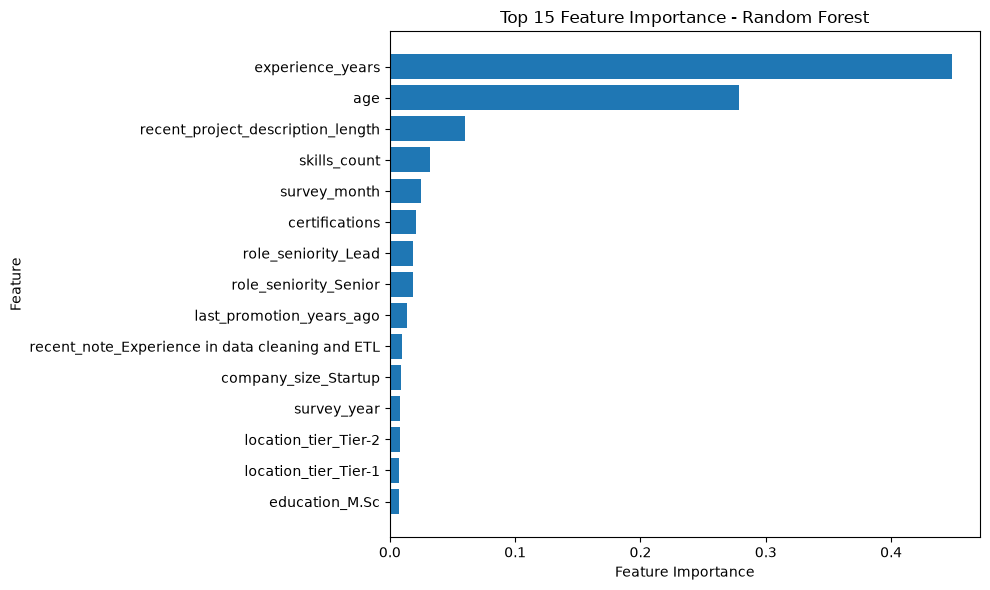

In [19]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - Random Forest")

plt.tight_layout()
plt.show()

Xây dựng RFE thủ công

Theo quy trình RFE:

1. Huấn luyện mô hình trên các feature hiện tại.
2. Lấy feature importance.
3. Tìm feature có importance thấp nhất.
4. Loại bỏ feature đó.
5. Lặp lại.

Ở đây, ta thực hiện quá trình trên cho đến khi chỉ còn 1 feature.

Việc xây dựng thủ công giúp quan sát rõ cách RFE hoạt động,
thay vì chỉ gọi trực tiếp hàm RFECV có sẵn của Scikit-learn.

In [20]:
def rfe_function(model, X, y, n_features_to_select=1):
    """
    Thực hiện Recursive Feature Elimination thủ công.

    Parameters
    ----------
    model : estimator
        Mô hình có thuộc tính feature_importances_.

    X : DataFrame
        Bộ dữ liệu đầu vào.

    y : Series
        Biến mục tiêu.

    n_features_to_select : int
        Số feature muốn giữ lại.

    Returns
    -------
    selected_features : list
        Danh sách feature được giữ lại.
    """

    features = list(X.columns)

    while len(features) > n_features_to_select:

        # Tạo model mới cho mỗi vòng lặp
        current_model = clone(model)

        # Huấn luyện trên các feature hiện tại
        current_model.fit(X[features], y)

        # Lấy feature importance
        importances = current_model.feature_importances_

        # Tìm feature ít quan trọng nhất
        lowest_index = np.argmin(importances)

        # Xóa feature đó
        features.pop(lowest_index)

    return features

 Kiểm tra quá trình RFE

Để minh họa kết quả của RFE, ta có thể yêu cầu thuật toán giữ lại
một số lượng feature cụ thể.

Ví dụ: giữ lại 10 feature.

Lưu ý rằng đây mới chỉ là RFE.
Chúng ta chưa biết 10 có phải là số feature tối ưu hay không.

Việc tìm số lượng feature tối ưu sẽ được thực hiện bằng Cross-Validation.

In [21]:
selected_10_features = rfe_function(
    rf_model,
    X,
    y,
    n_features_to_select=10
)

print("10 feature được lựa chọn:")
for i, feature in enumerate(selected_10_features, 1):
    print(f"{i}. {feature}")

10 feature được lựa chọn:
1. age
2. experience_years
3. skills_count
4. certifications
5. last_promotion_years_ago
6. recent_project_description_length
7. survey_month
8. role_seniority_Lead
9. role_seniority_Senior
10. company_size_Startup


### Kết hợp RFE với 5-Fold Cross-Validation

RFE chỉ cho biết thứ tự loại bỏ feature. Để xác định số lượng feature phù hợp, ta kết hợp RFE với Cross-Validation.

Trong notebook này:
- Sử dụng **5-Fold Cross-Validation**.
- Giữ Random Forest làm mô hình cơ sở.
- Sử dụng **R²** làm thước đo vì `salary_bdt` là biến liên tục.
- Để giảm thời gian chạy, ta dùng `step=2`, tức là sau mỗi vòng sẽ loại 2 feature ít quan trọng nhất thay vì loại từng feature. Đây vẫn giữ đúng ý tưởng RFE/RFECV và phù hợp với ghi chú trong bài học về việc lựa chọn step size phù hợp. fileciteturn13file0

In [22]:
def rfe_function_cv_fast(model, X, y, cv, step=2):
    """
    RFE + 5-Fold Cross-Validation phiên bản tối ưu thời gian.

    step=2: mỗi vòng loại 2 feature ít quan trọng nhất.
    Vẫn sử dụng 5-fold CV để đánh giá từng tập feature.
    """
    current_features = list(X.columns)
    mean_scores = []
    feature_sets = {}

    while len(current_features) >= 1:
        n_current = len(current_features)
        feature_sets[n_current] = current_features.copy()

        fold_scores = []

        for train_idx, test_idx in cv.split(X):
            X_train = X.iloc[train_idx][current_features]
            X_test = X.iloc[test_idx][current_features]
            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            current_model = clone(model)
            current_model.fit(X_train, y_train)

            y_pred = current_model.predict(X_test)
            fold_scores.append(r2_score(y_test, y_pred))

        mean_scores.append({
            "Number_of_Features": n_current,
            "Mean_R2": np.mean(fold_scores),
            "Std_R2": np.std(fold_scores)
        })

        if n_current <= 1:
            break

        # Fit một lần trên toàn bộ dữ liệu để tìm feature ít quan trọng nhất
        ranking_model = clone(model)
        ranking_model.fit(X[current_features], y)

        importances = ranking_model.feature_importances_
        remove_n = min(step, n_current - 1)

        # Loại các feature có importance thấp nhất
        remove_indices = np.argsort(importances)[:remove_n]
        current_features = [
            f for i, f in enumerate(current_features)
            if i not in remove_indices
        ]

    results = pd.DataFrame(mean_scores).sort_values(
        "Number_of_Features"
    ).reset_index(drop=True)

    return results, feature_sets

### Thực hiện RFE + 5-Fold Cross-Validation

Ở bước này:
1. Bắt đầu với toàn bộ feature.
2. Đánh giá bằng 5-Fold CV.
3. Dựa vào feature importance của Random Forest để loại feature yếu nhất.
4. Lặp lại cho đến khi còn 1 feature.
5. Chọn số feature có Mean R² cao nhất.

In [23]:
# Giữ nguyên 5-Fold Cross-Validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# RFECV tối ưu thời gian
rfecv_results, feature_sets = rfe_function_cv_fast(
    rf_model,
    X,
    y,
    kf,
    step=2
)

best_row = rfecv_results.loc[
    rfecv_results["Mean_R2"].idxmax()
]

best_n_features = int(best_row["Number_of_Features"])
best_r2 = best_row["Mean_R2"]

selected_features = feature_sets[best_n_features]
X_rfecv = X[selected_features].copy()

print("===== KẾT QUẢ RFECV =====")
print("Số features ban đầu:", X.shape[1])
print("Số features tối ưu:", best_n_features)
print("Mean R² tốt nhất:", round(best_r2, 4))
print("\nFeatures được chọn:")
print(selected_features)

===== KẾT QUẢ RFECV =====
Số features ban đầu: 27
Số features tối ưu: 27
Mean R² tốt nhất: 0.6744

Features được chọn:
['age', 'experience_years', 'skills_count', 'certifications', 'worked_remote', 'last_promotion_years_ago', 'recent_project_description_length', 'survey_year', 'survey_month', 'gender_Male', 'gender_Other', 'education_B.Sc+Cert', 'education_M.Eng', 'education_M.Sc', 'education_PhD', 'role_seniority_Lead', 'role_seniority_Mid', 'role_seniority_Senior', 'company_size_SME', 'company_size_Startup', 'location_tier_Tier-1', 'location_tier_Tier-2', 'location_tier_Tier-3', 'recent_note_Contributed to open-source NLP repo', 'recent_note_Experience in data cleaning and ETL', 'recent_note_No relevant project mentioned', 'recent_note_Worked on microservices deployment']


### Biểu đồ Mean R² theo số lượng feature

Biểu đồ giúp quan sát số lượng feature tại đó mô hình đạt Mean R² cao nhất.

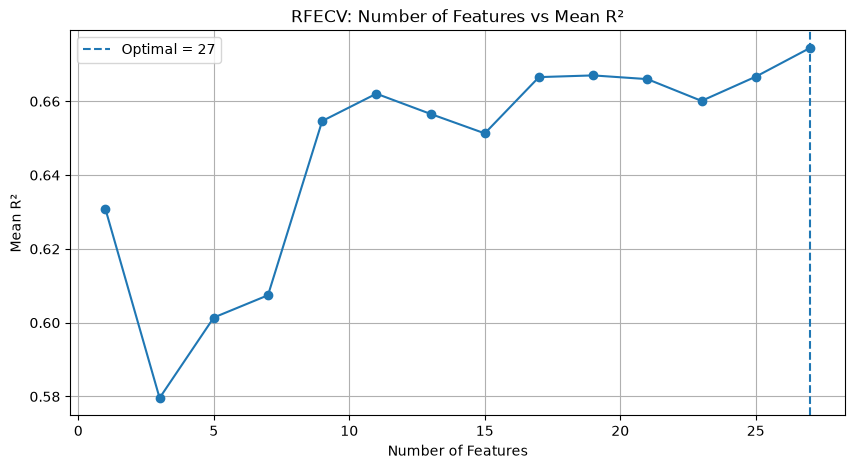

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(
    rfecv_results["Number_of_Features"],
    rfecv_results["Mean_R2"],
    marker="o"
)
plt.axvline(
    best_n_features,
    linestyle="--",
    label=f"Optimal = {best_n_features}"
)
plt.xlabel("Number of Features")
plt.ylabel("Mean R²")
plt.title("RFECV: Number of Features vs Mean R²")
plt.legend()
plt.grid(True)
plt.show()

### Kiểm tra danh sách feature được RFECV lựa chọn

RFECV là một phương pháp **Feature Selection**, vì vậy các feature sau khi chọn vẫn là các biến ban đầu, không tạo ra biến mới. Điều này khác với PCA/SVD, là các phương pháp Feature Extraction.

In [25]:
rfecv_feature_table = pd.DataFrame({
    "Selected_Feature": selected_features
})

display(rfecv_feature_table)

,Selected_Feature
0,age
1,experience_years
2,skills_count
3,certifications
4,worked_remote
5,last_promotion_years_ago
6,recent_project_description_length
7,survey_year
8,survey_month
9,gender_Male


## 2. Variance Threshold

Variance Threshold là một **Filter Method** dùng để loại bỏ các feature có mức độ biến thiên quá thấp.

Ý tưởng:
- Nếu một feature gần như không thay đổi giữa các quan sát, feature đó thường cung cấp rất ít thông tin phân biệt.
- Phương pháp này **không sử dụng target `salary_bdt`**.
- Sau preprocessing, dữ liệu `X` đã ở dạng số nên có thể tính variance trực tiếp.

Trong bài này chọn:

`threshold = 0.01`

Feature có variance `< 0.01` sẽ bị loại. Ngưỡng này được chọn ở mức thấp để chỉ loại các biến thực sự gần như không biến thiên, tránh loại quá nhiều feature.

In [26]:
from sklearn.feature_selection import VarianceThreshold

variance_threshold = 0.01

# Tính variance của từng feature trước khi lọc
variance_table = pd.DataFrame({
    "Feature": X.columns,
    "Variance": X.var()
}).sort_values("Variance", ascending=True)

display(variance_table)

# Áp dụng Variance Threshold
vt_selector = VarianceThreshold(threshold=variance_threshold)
X_vt_array = vt_selector.fit_transform(X)

vt_features = X.columns[vt_selector.get_support()].tolist()

X_variance = pd.DataFrame(
    X_vt_array,
    columns=vt_features,
    index=X.index
)

print("===== KẾT QUẢ VARIANCE THRESHOLD =====")
print("Ngưỡng variance:", variance_threshold)
print("Số features ban đầu:", X.shape[1])
print("Số features sau lọc:", X_variance.shape[1])
print("Số features bị loại:", X.shape[1] - X_variance.shape[1])

print("\nFeatures bị loại:")
print([f for f in X.columns if f not in vt_features])

,Feature,Variance
gender_Other,gender_Other,0.016236
education_PhD,education_PhD,0.027702
education_M.Eng,education_M.Eng,0.047073
role_seniority_Lead,role_seniority_Lead,0.047974
education_B.Sc+Cert,education_B.Sc+Cert,0.101440
location_tier_Tier-3,location_tier_Tier-3,0.107925
recent_note_Experience in data cleaning and ETL,recent_note_Experience in data cleaning and ETL,0.110553
recent_note_Worked on microservices deployment,recent_note_Worked on microservices deployment,0.135485
recent_note_Contributed to open-source NLP repo,recent_note_Contributed to open-source NLP repo,0.138513
recent_note_No relevant project mentioned,recent_note_No relevant project mentioned,0.145744


===== KẾT QUẢ VARIANCE THRESHOLD =====
Ngưỡng variance: 0.01
Số features ban đầu: 27
Số features sau lọc: 27
Số features bị loại: 0

Features bị loại:
[]


### Nhận xét Variance Threshold

Bảng variance cho biết mức độ biến thiên của từng feature.

- Feature có variance rất nhỏ sẽ được xem xét loại bỏ.
- Nếu không có feature nào dưới ngưỡng `0.01`, số chiều sẽ không thay đổi.
- Đây vẫn là một kết quả hợp lệ: nó cho thấy dataset không có feature gần như hằng số theo ngưỡng đã chọn.

Variance Threshold nên được xem là **bước lọc ban đầu**, vì phương pháp này không xét trực tiếp mối quan hệ giữa feature và `salary_bdt`.

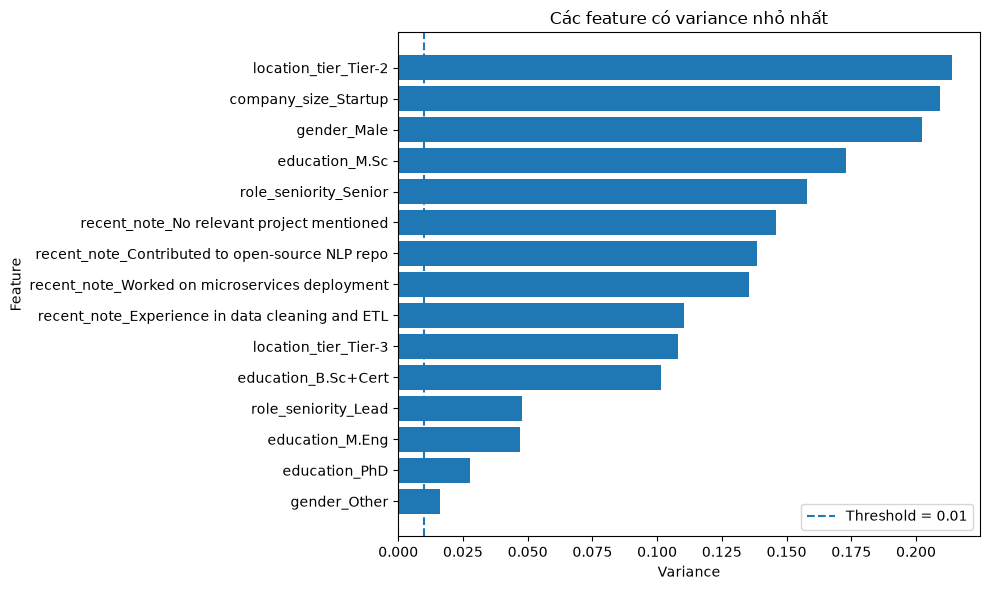

In [27]:
# Trực quan các feature có variance nhỏ nhất
top_variance = variance_table.head(min(15, len(variance_table)))

plt.figure(figsize=(10, 6))
plt.barh(top_variance["Feature"], top_variance["Variance"])
plt.axvline(
    variance_threshold,
    linestyle="--",
    label=f"Threshold = {variance_threshold}"
)
plt.xlabel("Variance")
plt.ylabel("Feature")
plt.title("Các feature có variance nhỏ nhất")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Correlation Feature Selection

Correlation Feature Selection cũng là một **Filter Method**.

Mục tiêu ở đây là loại các feature có tương quan quá cao với nhau, từ đó giảm thông tin trùng lặp và giảm multicollinearity.

Quy trình:
1. Tính ma trận tương quan Pearson giữa các feature.
2. Lấy trị tuyệt đối `|r|`.
3. Chỉ xét nửa trên của ma trận để tránh kiểm tra một cặp hai lần.
4. Nếu `|r| >= 0.80`, giữ feature xuất hiện trước và loại feature còn lại.

**Lưu ý:** phương pháp này chỉ xét quan hệ giữa các feature với nhau, không đánh giá trực tiếp feature nào dự đoán `salary_bdt` tốt hơn.

In [28]:
corr_threshold = 0.80

# Ma trận tương quan tuyệt đối
corr_matrix = X.corr().abs()

# Chỉ lấy tam giác trên của ma trận
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Tìm các cặp feature có tương quan cao
high_corr_pairs = []

for column in upper_triangle.columns:
    for row in upper_triangle.index:
        value = upper_triangle.loc[row, column]
        if pd.notna(value) and value >= corr_threshold:
            high_corr_pairs.append({
                "Feature_1": row,
                "Feature_2": column,
                "Abs_Correlation": value
            })

high_corr_pairs = pd.DataFrame(high_corr_pairs)

if len(high_corr_pairs) > 0:
    high_corr_pairs = high_corr_pairs.sort_values(
        "Abs_Correlation",
        ascending=False
    ).reset_index(drop=True)

# Loại feature có tương quan cao với một feature đứng trước nó
corr_drop = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] >= corr_threshold)
]

corr_features = [
    column for column in X.columns
    if column not in corr_drop
]

X_correlation = X[corr_features].copy()

print("===== KẾT QUẢ CORRELATION =====")
print("Ngưỡng |r|:", corr_threshold)
print("Số features ban đầu:", X.shape[1])
print("Số features sau lọc:", X_correlation.shape[1])
print("Số features bị loại:", len(corr_drop))

print("\nFeatures bị loại:")
print(corr_drop)

print("\nCác cặp có tương quan cao:")
if len(high_corr_pairs) > 0:
    display(high_corr_pairs)
else:
    print("Không có cặp feature nào đạt ngưỡng.")

===== KẾT QUẢ CORRELATION =====
Ngưỡng |r|: 0.8
Số features ban đầu: 27
Số features sau lọc: 26
Số features bị loại: 1

Features bị loại:
['experience_years']

Các cặp có tương quan cao:


,Feature_1,Feature_2,Abs_Correlation
0,age,experience_years,0.897403


### Ma trận tương quan

Ma trận dưới đây giúp quan sát trực tiếp mức độ tương quan giữa các feature.

Các giá trị gần `1` cho thấy hai feature có quan hệ tuyến tính mạnh. Trong bài này, ngưỡng `0.80` được dùng để xác định các cặp có tương quan cao.

,age,experience_years,skills_count,certifications,worked_remote,last_promotion_years_ago,recent_project_description_length,survey_year,survey_month,gender_Male,...,role_seniority_Senior,company_size_SME,company_size_Startup,location_tier_Tier-1,location_tier_Tier-2,location_tier_Tier-3,recent_note_Contributed to open-source NLP repo,recent_note_Experience in data cleaning and ETL,recent_note_No relevant project mentioned,recent_note_Worked on microservices deployment
age,1.00,0.90,0.01,0.03,0.03,0.02,0.00,0.01,0.01,0.05,...,0.00,0.02,0.01,0.02,0.01,0.02,0.03,0.02,0.01,0.00
experience_years,0.90,1.00,0.03,0.03,0.04,0.02,0.01,0.01,0.00,0.04,...,0.00,0.01,0.02,0.02,0.01,0.01,0.03,0.02,0.02,0.01
skills_count,0.01,0.03,1.00,0.01,0.01,0.00,0.00,0.01,0.05,0.02,...,0.02,0.03,0.03,0.03,0.01,0.04,0.01,0.03,0.01,0.02
certifications,0.03,0.03,0.01,1.00,0.04,0.00,0.02,0.04,0.02,0.01,...,0.00,0.01,0.01,0.00,0.03,0.03,0.03,0.01,0.02,0.00
worked_remote,0.03,0.04,0.01,0.04,1.00,0.02,0.01,0.01,0.02,0.02,...,0.01,0.01,0.01,0.02,0.02,0.01,0.05,0.04,0.01,0.01
last_promotion_years_ago,0.02,0.02,0.00,0.00,0.02,1.00,0.03,0.01,0.02,0.03,...,0.02,0.01,0.03,0.00,0.02,0.02,0.05,0.02,0.03,0.01
recent_project_description_length,0.00,0.01,0.00,0.02,0.01,0.03,1.00,0.01,0.00,0.01,...,0.01,0.01,0.01,0.01,0.01,0.02,0.03,0.01,0.02,0.01
survey_year,0.01,0.01,0.01,0.04,0.01,0.01,0.01,1.00,0.03,0.03,...,0.01,0.00,0.00,0.00,0.01,0.02,0.00,0.00,0.02,0.00
survey_month,0.01,0.00,0.05,0.02,0.02,0.02,0.00,0.03,1.00,0.04,...,0.01,0.00,0.02,0.03,0.01,0.06,0.03,0.01,0.05,0.02
gender_Male,0.05,0.04,0.02,0.01,0.02,0.03,0.01,0.03,0.04,1.00,...,0.03,0.02,0.00,0.00,0.02,0.01,0.00,0.06,0.01,0.02


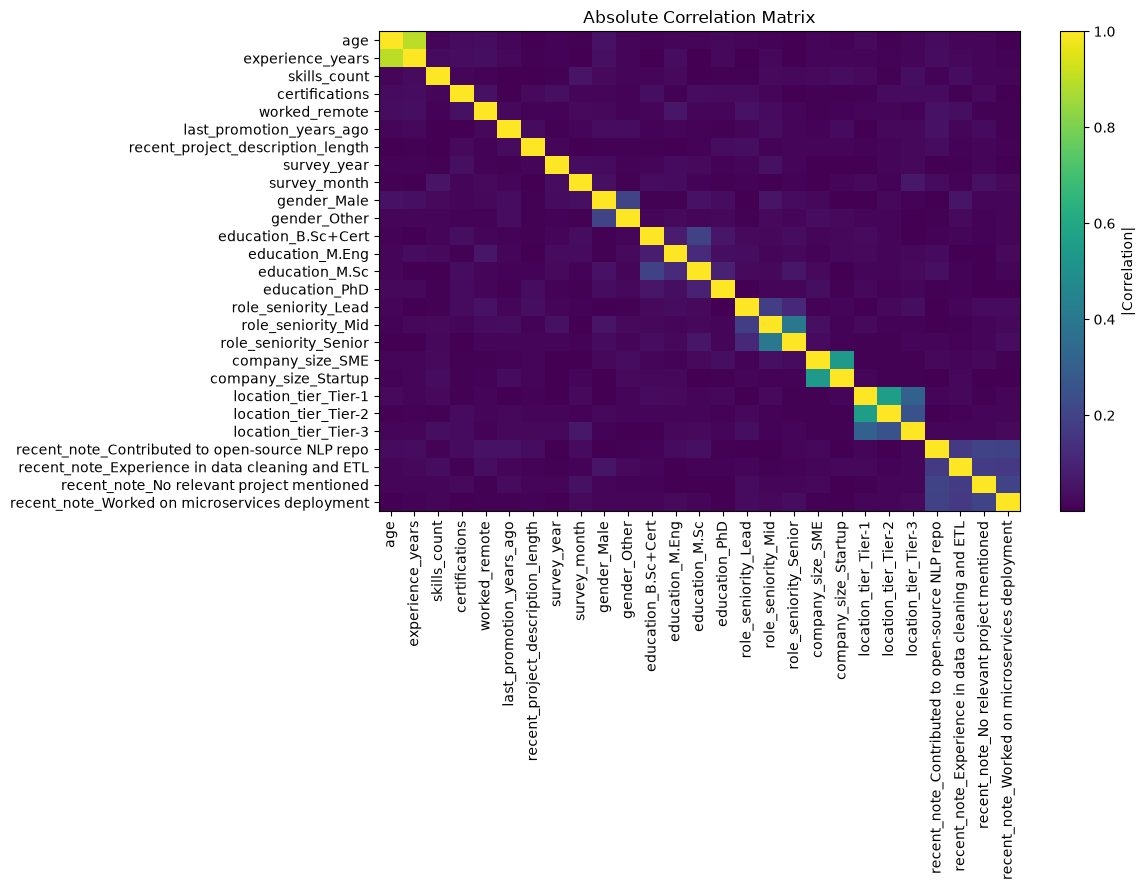

In [29]:
display(corr_matrix.round(2))

plt.figure(figsize=(12, 9))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="|Correlation|")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Absolute Correlation Matrix")
plt.tight_layout()
plt.show()

## 4. Random Forest Feature Importance

Random Forest Feature Importance là một **Embedded Method**.

Quy trình:
1. Huấn luyện Random Forest Regression trên toàn bộ feature.
2. Lấy `feature_importances_` từ mô hình.
3. Sắp xếp feature theo Importance giảm dần.
4. Dùng **median importance** làm ngưỡng chọn feature.

Việc dùng median thay vì tự đặt một giá trị Importance cố định giúp ngưỡng thích nghi với chính dataset. Các feature có Importance lớn hơn hoặc bằng median sẽ được giữ lại.

In [30]:
rf_importance_model = RandomForestRegressor(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)

rf_importance_model.fit(X, y)

importance_table = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_importance_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

importance_threshold = importance_table["Importance"].median()

rf_importance_features = importance_table.loc[
    importance_table["Importance"] >= importance_threshold,
    "Feature"
].tolist()

X_rf_importance = X[rf_importance_features].copy()

print("===== KẾT QUẢ RANDOM FOREST IMPORTANCE =====")
print("Importance median:", round(importance_threshold, 6))
print("Số features ban đầu:", X.shape[1])
print("Số features giữ lại:", X_rf_importance.shape[1])
print("Số features bị loại:", X.shape[1] - X_rf_importance.shape[1])

print("\nFeatures được giữ lại:")
print(rf_importance_features)

===== KẾT QUẢ RANDOM FOREST IMPORTANCE =====
Importance median: 0.007524
Số features ban đầu: 27
Số features giữ lại: 14
Số features bị loại: 13

Features được giữ lại:
['experience_years', 'age', 'recent_project_description_length', 'skills_count', 'survey_month', 'role_seniority_Lead', 'certifications', 'last_promotion_years_ago', 'role_seniority_Senior', 'recent_note_Experience in data cleaning and ETL', 'company_size_Startup', 'role_seniority_Mid', 'location_tier_Tier-1', 'location_tier_Tier-2']


### Biểu đồ Feature Importance

Biểu đồ giúp quan sát trực quan những feature đóng góp nhiều hơn cho Random Forest.

Feature có Importance cao không có nghĩa là feature đó có quan hệ nhân quả với salary; nó chỉ phản ánh mức độ mô hình Random Forest sử dụng feature đó trong quá trình dự đoán.

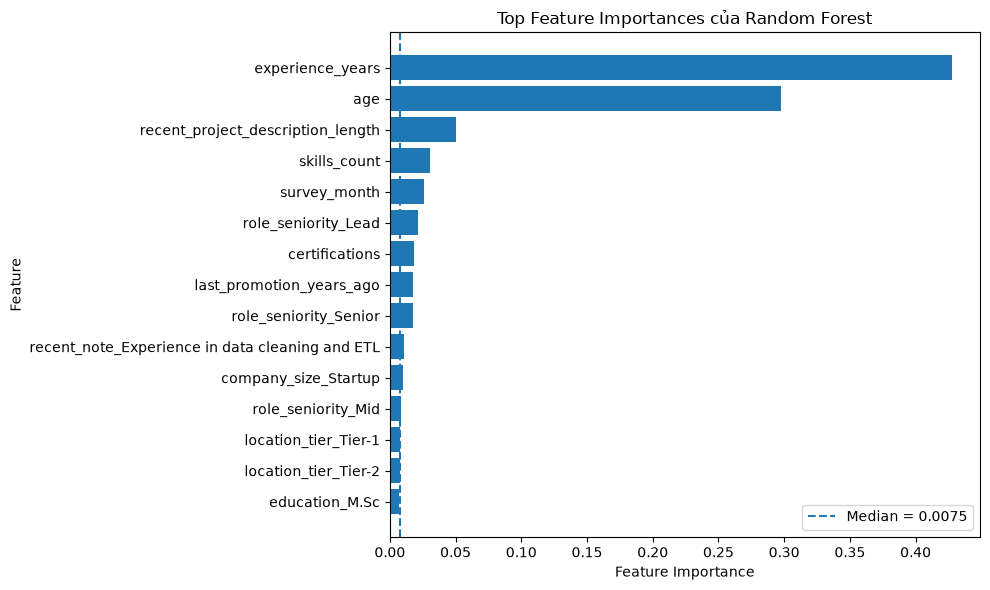

In [31]:
top_n = min(15, len(importance_table))
top_importance = importance_table.head(top_n).sort_values("Importance")

plt.figure(figsize=(10, 6))
plt.barh(
    top_importance["Feature"],
    top_importance["Importance"]
)
plt.axvline(
    importance_threshold,
    linestyle="--",
    label=f"Median = {importance_threshold:.4f}"
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Feature Importances của Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

## 5. PCA - Principal Component Analysis

PCA là phương pháp **Feature Extraction**. PCA không chọn một số feature ban đầu mà tạo ra các **Principal Components** mới.

Phần này được thực hiện theo logic của notebook PCA mẫu:

1. Chia dữ liệu thành **training set và test set**.
2. Chuẩn hóa dữ liệu bằng `StandardScaler` — đây là bước quan trọng trước PCA.
3. Fit PCA trên training set.
4. Tính `explained_variance_ratio_`.
5. Tính phương sai tích lũy.
6. Chọn số component nhỏ nhất giải thích ít nhất **95% tổng phương sai**.
7. Transform cả training và test bằng các component đã chọn.

Cách này giúp tránh việc PCA học từ test set.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Chia train/test
X_train_pca_raw, X_test_pca_raw, y_train_pca, y_test_pca = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

# 2. Chuẩn hóa - chỉ fit trên training set
scaler_pca = StandardScaler()
X_train_std = scaler_pca.fit_transform(X_train_pca_raw)
X_test_std = scaler_pca.transform(X_test_pca_raw)

print("X_train trước PCA:", X_train_pca_raw.shape)
print("X_test trước PCA:", X_test_pca_raw.shape)

# 3. Fit PCA với toàn bộ components trước
pca = PCA()
X_train_pca_all = pca.fit_transform(X_train_std)
X_test_pca_all = pca.transform(X_test_std)

# 4. Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 5. Chọn số component nhỏ nhất đạt 95%
variance_target = 0.95

n_components_pca = 1 + np.argmax(
    cumulative_variance >= variance_target
)

# 6. Giữ lại các component cần thiết
X_train_pca = X_train_pca_all[:, :n_components_pca]
X_test_pca = X_test_pca_all[:, :n_components_pca]

pca_columns = [
    f"PC{i+1}" for i in range(n_components_pca)
]

# Tạo biểu diễn PCA của toàn bộ X để dùng cho bảng mô tả kết quả
X_all_std = scaler_pca.transform(X)
X_pca_array = pca.transform(X_all_std)[:, :n_components_pca]

X_pca = pd.DataFrame(
    X_pca_array,
    columns=pca_columns,
    index=X.index
)

print("\n===== KẾT QUẢ PCA =====")
print("Số features ban đầu:", X.shape[1])
print("Variance target:", variance_target)
print("Số Principal Components:", n_components_pca)
print(
    "Cumulative explained variance:",
    round(cumulative_variance[n_components_pca - 1], 4)
)

X_train trước PCA: (1500, 27)
X_test trước PCA: (500, 27)

===== KẾT QUẢ PCA =====
Số features ban đầu: 27
Variance target: 0.95
Số Principal Components: 23
Cumulative explained variance: 0.9553


### Explained Variance của PCA

`Explained_Variance_Ratio` cho biết mỗi Principal Component giải thích bao nhiêu phần phương sai của dữ liệu.

`Cumulative_Variance` là tổng tích lũy của các component từ đầu đến component hiện tại.

Ta chọn component đầu tiên mà `Cumulative_Variance >= 95%`. Đây là cách giải thích trực quan cho việc lựa chọn số chiều.

,Component,Explained_Variance_Ratio,Cumulative_Variance
0,1,0.071459,0.071459
1,2,0.059400,0.130860
2,3,0.056928,0.187788
3,4,0.053667,0.241455
4,5,0.049042,0.290497
5,6,0.047687,0.338183
6,7,0.046740,0.384924
7,8,0.045708,0.430631
8,9,0.044613,0.475245
9,10,0.042751,0.517995


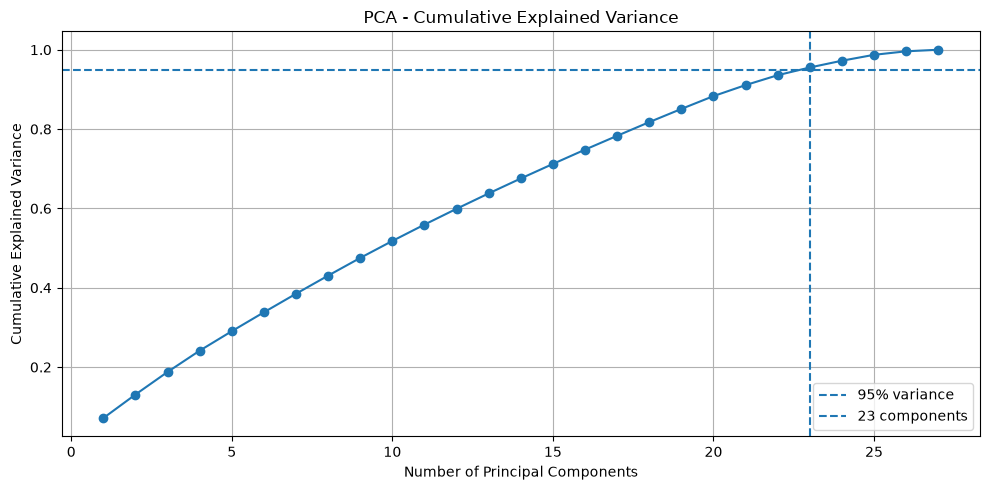

In [33]:
pca_variance = pd.DataFrame({
    "Component": range(1, len(explained_variance) + 1),
    "Explained_Variance_Ratio": explained_variance,
    "Cumulative_Variance": cumulative_variance
})

display(pca_variance)

plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.axhline(
    y=variance_target,
    linestyle="--",
    label="95% variance"
)
plt.axvline(
    x=n_components_pca,
    linestyle="--",
    label=f"{n_components_pca} components"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. SVD - Singular Value Decomposition

SVD (Singular Value Decomposition) phân rã một ma trận dữ liệu thành các thành phần dựa trên singular values.

Dạng tổng quát:

`X = UΣVᵀ`

Trong bài này sử dụng `TruncatedSVD` để giữ lại một số lượng component nhỏ hơn số feature ban đầu.

Quy trình:
1. Sử dụng dữ liệu số `X`.
2. Chuẩn hóa dữ liệu trước để giảm ảnh hưởng của khác biệt thang đo.
3. Thực hiện `TruncatedSVD`.
4. Kiểm tra `explained_variance_ratio_`.
5. Chọn **5 components** để tạo biểu diễn có số chiều thấp hơn rõ rệt.

SVD khác PCA ở cách xử lý ma trận: PCA thường gắn với covariance matrix và yêu cầu centering; `TruncatedSVD` làm việc trực tiếp trên ma trận dữ liệu và đặc biệt hữu ích với dữ liệu lớn/thưa.

In [34]:
from sklearn.decomposition import TruncatedSVD

# Chuẩn hóa dữ liệu trước khi thực hiện SVD
scaler_svd = StandardScaler()
X_svd_scaled = scaler_svd.fit_transform(X)

n_components_svd = min(5, X.shape[1] - 1)

svd = TruncatedSVD(
    n_components=n_components_svd,
    random_state=42
)

X_svd_array = svd.fit_transform(X_svd_scaled)

svd_columns = [
    f"SVD{i+1}" for i in range(n_components_svd)
]

X_svd = pd.DataFrame(
    X_svd_array,
    columns=svd_columns,
    index=X.index
)

print("===== KẾT QUẢ SVD =====")
print("Số features ban đầu:", X.shape[1])
print("Số SVD components:", X_svd.shape[1])
print(
    "Tổng explained variance của 5 components:",
    round(svd.explained_variance_ratio_.sum(), 4)
)

===== KẾT QUẢ SVD =====
Số features ban đầu: 27
Số SVD components: 5
Tổng explained variance của 5 components: 0.288


### Explained Variance của SVD

Tương tự PCA, `explained_variance_ratio_` cho biết lượng biến thiên được giải thích bởi từng SVD component.

Vì bài tập yêu cầu áp dụng SVD để giảm chiều, ta theo dõi cả phương sai từng component và phương sai tích lũy.

,Component,Explained_Variance_Ratio,Cumulative_Variance
0,SVD1,0.071228,0.071228
1,SVD2,0.058139,0.129368
2,SVD3,0.057579,0.186946
3,SVD4,0.053352,0.240298
4,SVD5,0.047691,0.287990


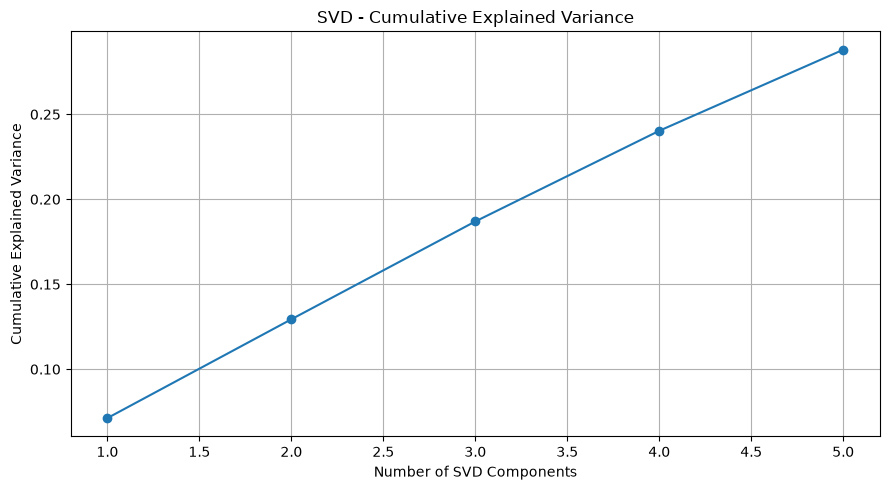

In [35]:
svd_explained = svd.explained_variance_ratio_
svd_cumulative = np.cumsum(svd_explained)

svd_variance = pd.DataFrame({
    "Component": svd_columns,
    "Explained_Variance_Ratio": svd_explained,
    "Cumulative_Variance": svd_cumulative
})

display(svd_variance)

plt.figure(figsize=(9, 5))
plt.plot(
    range(1, len(svd_cumulative) + 1),
    svd_cumulative,
    marker="o"
)
plt.xlabel("Number of SVD Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("SVD - Cumulative Explained Variance")
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. LDA - Linear Discriminant Analysis

LDA (Linear Discriminant Analysis) là phương pháp **supervised dimensionality reduction** vì nó sử dụng class label khi tìm các hướng chiếu.

Dataset hiện tại có `salary_bdt` là biến liên tục, trong khi LDA yêu cầu class label. Vì vậy, để minh họa LDA trên dataset này:

- Chia `salary_bdt` thành 3 nhóm bằng tertile:
  - `Low`
  - `Medium`
  - `High`
- Sau đó dùng các feature `X` để tìm các discriminant components.

Với `K = 3` classes, số component tối đa là:

`K - 1 = 2`

Do đó chọn `n_components = 2`.

**Lưu ý:** LDA trong bài này là một ví dụ về dimensionality reduction cho classification, không phải mô hình hồi quy trực tiếp dự đoán mức salary liên tục.

In [36]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Chuyển salary liên tục thành 3 class có số lượng quan sát tương đối cân bằng
salary_class = pd.qcut(
    y,
    q=3,
    labels=["Low", "Medium", "High"]
)

print("===== PHÂN BỐ CLASS CHO LDA =====")
print(salary_class.value_counts().sort_index())

print("\nTỷ lệ từng class:")
print(
    salary_class.value_counts(normalize=True)
    .sort_index()
    .round(4)
)

===== PHÂN BỐ CLASS CHO LDA =====
salary_bdt
Low       667
Medium    666
High      667
Name: count, dtype: int64

Tỷ lệ từng class:
salary_bdt
Low       0.3335
Medium    0.3330
High      0.3335
Name: proportion, dtype: float64


In [37]:
# Chuẩn hóa dữ liệu trước LDA
scaler_lda = StandardScaler()
X_lda_scaled = scaler_lda.fit_transform(X)

# Với 3 classes, tối đa 2 discriminant components
lda = LinearDiscriminantAnalysis(
    n_components=2
)

X_lda_array = lda.fit_transform(
    X_lda_scaled,
    salary_class
)

lda_columns = ["LD1", "LD2"]

X_lda = pd.DataFrame(
    X_lda_array,
    columns=lda_columns,
    index=X.index
)

print("===== KẾT QUẢ LDA =====")
print("Số features ban đầu:", X.shape[1])
print("Số classes:", salary_class.nunique())
print("Số LDA components:", X_lda.shape[1])

if hasattr(lda, "explained_variance_ratio_"):
    print(
        "Explained variance ratio:",
        np.round(lda.explained_variance_ratio_, 4)
    )

===== KẾT QUẢ LDA =====
Số features ban đầu: 27
Số classes: 3
Số LDA components: 2
Explained variance ratio: [0.9908 0.0092]


### Đánh giá LDA

Vì LDA đang giải quyết bài toán phân loại 3 nhóm salary nên metric phù hợp là **Accuracy**, không phải MAE/RMSE/R².

Để đánh giá ổn định, sử dụng **5-Fold Cross-Validation** với cùng cách chia fold `kf` đã sử dụng ở phần RFECV.

In [38]:
from sklearn.pipeline import Pipeline

lda_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(n_components=2))
])

lda_scores = cross_val_score(
    lda_pipeline,
    X,
    salary_class,
    cv=kf,
    scoring="accuracy",
    n_jobs=-1
)

print("Accuracy từng fold:", np.round(lda_scores, 4))
print("Accuracy trung bình:", round(lda_scores.mean(), 4))
print("Accuracy std:", round(lda_scores.std(), 4))

Accuracy từng fold: [0.82   0.84   0.8175 0.83   0.8325]
Accuracy trung bình: 0.828
Accuracy std: 0.0083


## 8. So sánh Original với từng phương pháp

Mục tiêu của phần này là trả lời câu hỏi:

> Sau khi giảm hoặc chọn feature, mô hình Random Forest Regression dự đoán `salary_bdt` thay đổi như thế nào so với dữ liệu Original?

Để so sánh:
- Giữ cùng **5-Fold Cross-Validation**.
- Dùng cùng Random Forest Regression.
- Tính:
  - **MAE**: càng thấp càng tốt.
  - **RMSE**: càng thấp càng tốt.
  - **R²**: càng cao càng tốt.

Các phương pháp có thể so sánh trực tiếp trên bài toán hồi quy:
- Original
- RFECV
- Variance Threshold
- Correlation
- Random Forest Importance
- PCA
- SVD

**LDA không đưa vào bảng này**, vì LDA ở trên đã chuyển bài toán thành classification 3 lớp và được đánh giá bằng Accuracy.

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

def evaluate_regression_model(X_data, y_data, model=None, cv=None):
    if model is None:
        model = RandomForestRegressor(
            n_estimators=30,
            random_state=42,
            n_jobs=-1
        )

    if cv is None:
        cv = KFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

    maes = []
    rmses = []
    r2s = []

    for train_idx, test_idx in cv.split(X_data):
        X_train = X_data.iloc[train_idx]
        X_test = X_data.iloc[test_idx]
        y_train = y_data.iloc[train_idx]
        y_test = y_data.iloc[test_idx]

        model_fold = clone(model)
        model_fold.fit(X_train, y_train)

        pred = model_fold.predict(X_test)

        maes.append(mean_absolute_error(y_test, pred))
        rmses.append(
            np.sqrt(mean_squared_error(y_test, pred))
        )
        r2s.append(r2_score(y_test, pred))

    return {
        "MAE": np.mean(maes),
        "RMSE": np.mean(rmses),
        "R²": np.mean(r2s)
    }

In [40]:
comparison_data = {
    "Original": X,
    "RFECV": X_rfecv,
    "Variance Threshold": X_variance,
    "Correlation": X_correlation,
    "Random Forest Importance": X_rf_importance
}

comparison_results = []

# Feature Selection: dùng trực tiếp tập feature đã chọn
for method_name, X_method in comparison_data.items():
    metrics = evaluate_regression_model(
        X_method,
        y,
        model=RandomForestRegressor(
            n_estimators=30,
            random_state=42,
            n_jobs=-1
        ),
        cv=kf
    )

    comparison_results.append({
        "Method": method_name,
        "Features": X_method.shape[1],
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R²": metrics["R²"]
    })

# PCA: StandardScaler + PCA phải được fit bên trong từng fold
pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_pca))
])

pca_metrics = evaluate_regression_model(
    X,
    y,
    model=Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components_pca)),
        ("rf", RandomForestRegressor(
            n_estimators=30,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    cv=kf
)

comparison_results.append({
    "Method": "PCA",
    "Features": n_components_pca,
    "MAE": pca_metrics["MAE"],
    "RMSE": pca_metrics["RMSE"],
    "R²": pca_metrics["R²"]
})

# SVD: StandardScaler + TruncatedSVD bên trong từng fold
svd_metrics = evaluate_regression_model(
    X,
    y,
    model=Pipeline([
        ("scaler", StandardScaler()),
        ("svd", TruncatedSVD(
            n_components=n_components_svd,
            random_state=42
        )),
        ("rf", RandomForestRegressor(
            n_estimators=30,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    cv=kf
)

comparison_results.append({
    "Method": "SVD",
    "Features": n_components_svd,
    "MAE": svd_metrics["MAE"],
    "RMSE": svd_metrics["RMSE"],
    "R²": svd_metrics["R²"]
})

comparison_df = pd.DataFrame(comparison_results)

display(
    comparison_df.style.format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "R²": "{:.4f}"
    })
)

,Method,Features,MAE,RMSE,R²
0,Original,27,"15,945.24","30,722.12",0.6887
1,RFECV,27,"15,945.24","30,722.12",0.6887
2,Variance Threshold,27,"15,945.24","30,722.12",0.6887
3,Correlation,26,"21,455.45","35,628.64",0.5826
4,Random Forest Importance,14,"16,852.26","31,490.43",0.6734
5,PCA,23,"18,007.79","32,717.41",0.6469
6,SVD,5,"19,802.52","34,838.32",0.6001


### So sánh LDA

LDA được đánh giá riêng bằng Accuracy vì đây là bài toán phân loại 3 nhóm salary.

Bảng dưới đây so sánh:
- `Original classification`: dùng toàn bộ feature để phân loại Low/Medium/High.
- `LDA`: biểu diễn dữ liệu bằng 2 discriminant components rồi dùng Logistic Regression để kiểm tra khả năng phân loại trên không gian giảm chiều.

Việc dùng Logistic Regression ở đây chỉ nhằm đánh giá không gian LDA; nó không biến LDA thành bài toán hồi quy salary.

In [41]:
from sklearn.linear_model import LogisticRegression

original_lda_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lda_reduced_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(n_components=2)),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

original_lda_scores = cross_val_score(
    original_lda_pipeline,
    X,
    salary_class,
    cv=kf,
    scoring="accuracy",
    n_jobs=-1
)

lda_reduced_scores = cross_val_score(
    lda_reduced_pipeline,
    X,
    salary_class,
    cv=kf,
    scoring="accuracy",
    n_jobs=-1
)

lda_comparison = pd.DataFrame({
    "Method": [
        "Original classification",
        "LDA (2 components)"
    ],
    "Features / Components": [
        X.shape[1],
        2
    ],
    "Accuracy": [
        original_lda_scores.mean(),
        lda_reduced_scores.mean()
    ]
})

display(
    lda_comparison.style.format({
        "Accuracy": "{:.4f}"
    })
)

,Method,Features / Components,Accuracy
0,Original classification,27,0.8380
1,LDA (2 components),2,0.8380


## 9. Kết luận

Qua các phương pháp Feature Selection và Dimensionality Reduction, có thể rút ra các nhận xét sau:

1. **RFECV** kết hợp RFE với 5-Fold Cross-Validation để tìm số lượng feature dựa trên hiệu năng mô hình. Trong notebook này, `step=2` được sử dụng để giảm thời gian chạy nhưng vẫn giữ nguyên 5-fold.

2. **Variance Threshold** là phương pháp Filter đơn giản, nhanh và không phụ thuộc target. Nó đặc biệt phù hợp làm bước lọc ban đầu đối với các feature gần như không biến thiên.

3. **Correlation** tập trung loại thông tin trùng lặp giữa các feature. Phương pháp này hữu ích khi dataset có các biến tương quan mạnh, nhưng không trực tiếp đo khả năng dự đoán salary.

4. **Random Forest Feature Importance** là Embedded Method. Nó dùng chính mô hình Random Forest để xác định feature quan trọng và giữ lại nhóm feature có Importance từ mức median trở lên.

5. **PCA** là Feature Extraction. Theo logic của notebook mẫu, dữ liệu được chia train/test, chuẩn hóa trên training set, fit PCA trên training set và chọn số component dựa trên cumulative explained variance. Trong bài này sử dụng mức mục tiêu 95%.

6. **SVD** cũng là Feature Extraction nhưng dựa trên phép phân rã ma trận. `TruncatedSVD` được dùng để tạo 5 component và theo dõi explained variance.

7. **LDA** là Supervised Dimensionality Reduction. Vì `salary_bdt` là biến liên tục, bài này chuyển salary thành 3 nhóm Low/Medium/High. Với 3 classes, LDA tạo tối đa 2 components.

8. Bảng so sánh cuối cùng cho phép đánh giá đồng thời **mức giảm số chiều** và **hiệu năng dự đoán**. Không nên chỉ nhìn một metric duy nhất: một phương pháp có ít feature hơn nhưng R² giảm nhẹ có thể có ý nghĩa khác với một phương pháp giữ nhiều feature nhưng hiệu năng gần Original.

9. Cần phân biệt:
   - **Feature Selection:** RFECV, Variance Threshold, Correlation, Random Forest Importance.
   - **Feature Extraction:** PCA, SVD, LDA.

Nhìn chung, các phương pháp cho những góc nhìn khác nhau về việc giảm chiều dữ liệu. Feature Selection giữ lại các biến ban đầu nên dễ giải thích hơn, trong khi Feature Extraction tạo ra các biến mới và thường có khả năng giảm số chiều mạnh hơn.

### Ghi chú về thời gian chạy và tính nhất quán

Để notebook có thể hoàn thành trong thời gian giới hạn:

- RFECV vẫn giữ **5-Fold Cross-Validation**.
- RFECV sử dụng Random Forest với số cây nhỏ hơn và `step=2` để giảm số vòng RFE.
- Các Random Forest đánh giá cuối cùng dùng `n_estimators=30` để thời gian chạy hợp lý.
- PCA và SVD dùng pipeline khi đánh giá 5-fold để bước StandardScaler/PCA/SVD được fit riêng trong từng fold.
- LDA cũng dùng pipeline trong phần đánh giá.

Các kết quả trong notebook cần được đọc theo đúng metric của từng bài toán:
- Regression: MAE, RMSE, R².
- LDA classification: Accuracy.

**Lưu ý phương pháp:** các Filter/Embedded Feature Selection được thực hiện trên toàn bộ `X` trước phần đánh giá cuối để phù hợp với mục tiêu minh họa từng thuật toán trong bài lab. Trong một quy trình Machine Learning triển khai thực tế, bước chọn feature nên được đặt bên trong Cross-Validation/Pipeline để tránh data leakage.